In [1]:
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report
import matplotlib.pyplot as plt


In [2]:

# --- Load data ---
sig_df = pd.read_csv('data/pythia.csv', header=None)       # Signal file
bkg_df = pd.read_csv('data/herwig.csv', header=None)   # Background file

# --- Extract features (columns 0 through 8, 
X_sig = sig_df.iloc[:, 0:8].values   
X_bkg = bkg_df.iloc[:, 0:8].values   


In [3]:
# --- Create labels ---
y_sig = np.ones(len(X_sig))           # Signal → label 1
y_bkg = np.zeros(len(X_bkg))          # Background → label 0

# --- Combine into one dataset ---
X = np.concatenate([X_sig, X_bkg], axis=0)   # All features
y = np.concatenate([y_sig, y_bkg], axis=0)   # All labels


In [4]:
# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)


In [5]:
# --- Scale features (important for MLP) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit on train only
X_test_scaled = scaler.transform(X_test)         # Transform test


In [6]:
# --- Build and train MLP ---
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),   # 3 hidden layers
    activation='relu',                  # ReLU activation
    solver='adam',                       # Adam optimizer
    learning_rate_init=0.001,           # Initial learning rate
    max_iter=200,                       # Max epochs
    batch_size=64,                      # Mini-batch size
    early_stopping=True,                # Stop when validation plateaus
    validation_fraction=0.1,            # 10% of train for validation
    random_state=42
)

mlp.fit(X_train_scaled, y_train)        # Train

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",64
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of itera

In [7]:
# --- Evaluate ---
y_pred = mlp.predict(X_test_scaled)                    # Hard predictions
y_prob = mlp.predict_proba(X_test_scaled)[:, 1]        # Class 1 probability


In [8]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.9844
AUC-ROC:  0.9976
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99     26106
         1.0       0.97      0.99      0.98     23167

    accuracy                           0.98     49273
   macro avg       0.98      0.98      0.98     49273
weighted avg       0.98      0.98      0.98     49273



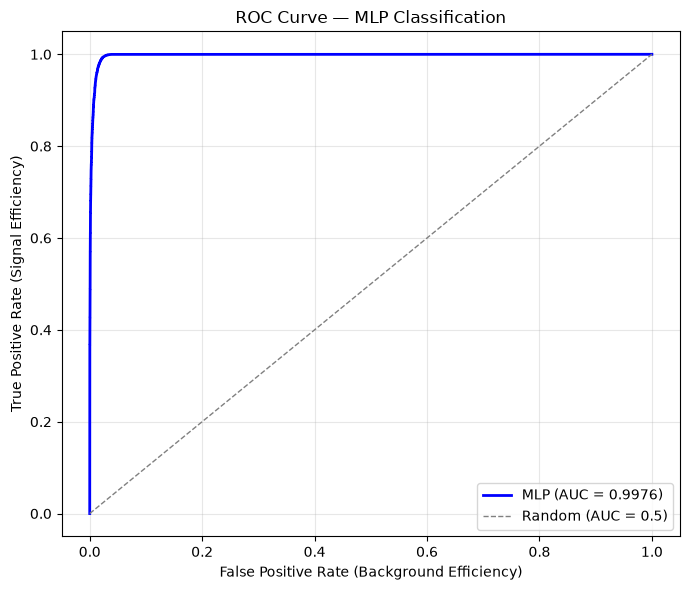

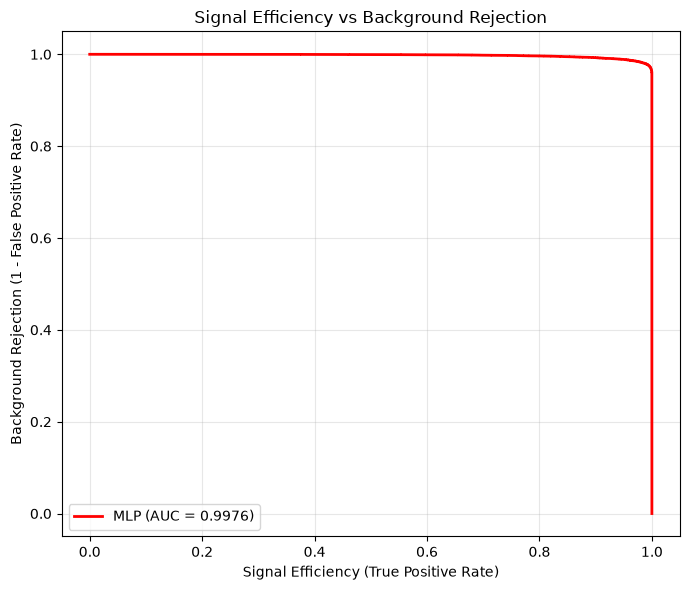

In [11]:

# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_prob)       # False/true positive rates
auc_score = roc_auc_score(y_test, y_prob)              # AUC value

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'MLP (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate (Background Efficiency)')
plt.ylabel('True Positive Rate (Signal Efficiency)')
plt.title('ROC Curve — MLP Classification')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_mlp.pdf')               # Save as PDF
plt.show()

# --- Optional: Signal efficiency vs Background rejection ---
plt.figure(figsize=(7, 6))
# Background rejection = 1 - FPR
plt.plot(tpr, 1.0 - fpr, color='red', lw=2, label=f'MLP (AUC = {auc_score:.4f})')
plt.xlabel('Signal Efficiency (True Positive Rate)')
plt.ylabel('Background Rejection (1 - False Positive Rate)')
plt.title('Signal Efficiency vs Background Rejection')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sig_eff_vs_bkg_rej.pdf')
plt.show()